In [1]:
from utils.custom_plots import (line_plot,
                                bar_plot, 
                                scatter_plot,
                                ecdf_plot)
from utils.db_utils import run_query
import pandas as pd
import numpy as np

import plotly.io as pio
pio.renderers.default = "png"       # drop this two lines to get local interactive plotly charts

<div class="alert alert-block alert-success">


## calculating revenue of delivr in different forms
- revenue per meal
- revenue per eatery
- revenue per month or week 
- revenue per customer(top n)

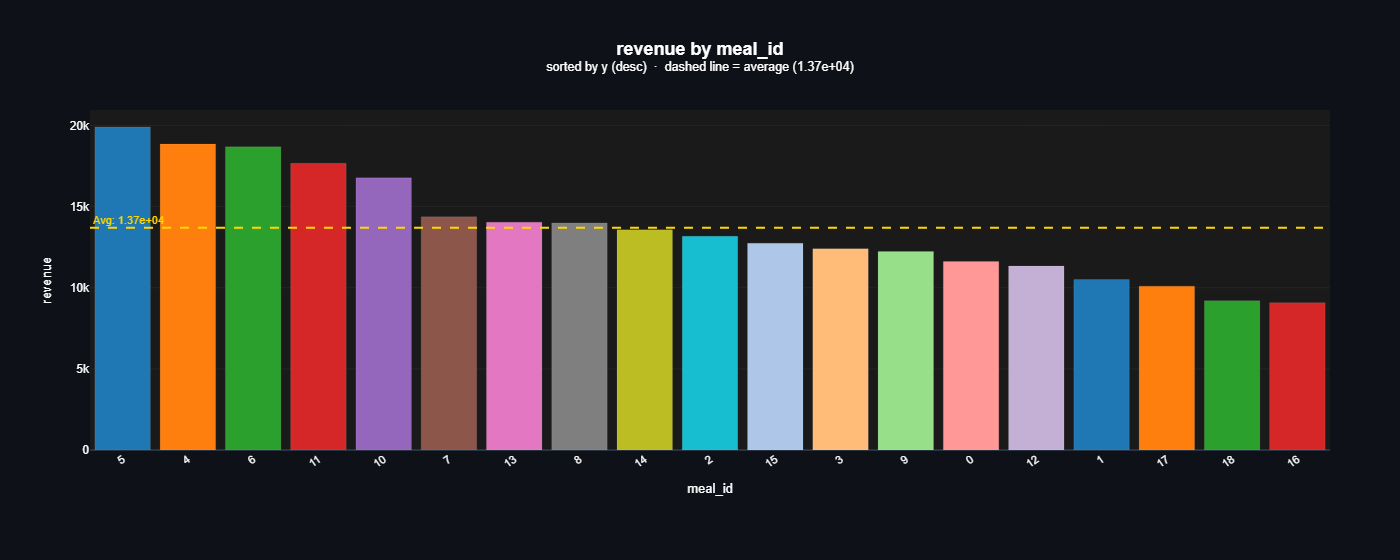

In [2]:
# revenue per meal 

df_revenue_permeal = run_query('''
select orders.meal_id,
       sum(meal_price * orders.order_quantity) as revenue 
from meals 
inner join orders using(meal_id)
group by orders.meal_id
''')

permeal_barplot = bar_plot(df=df_revenue_permeal, 
                           x='meal_id', 
                           y='revenue', 
                           show_values=False, 
                           sort_by='y', 
                           avg_line=True)
permeal_barplot

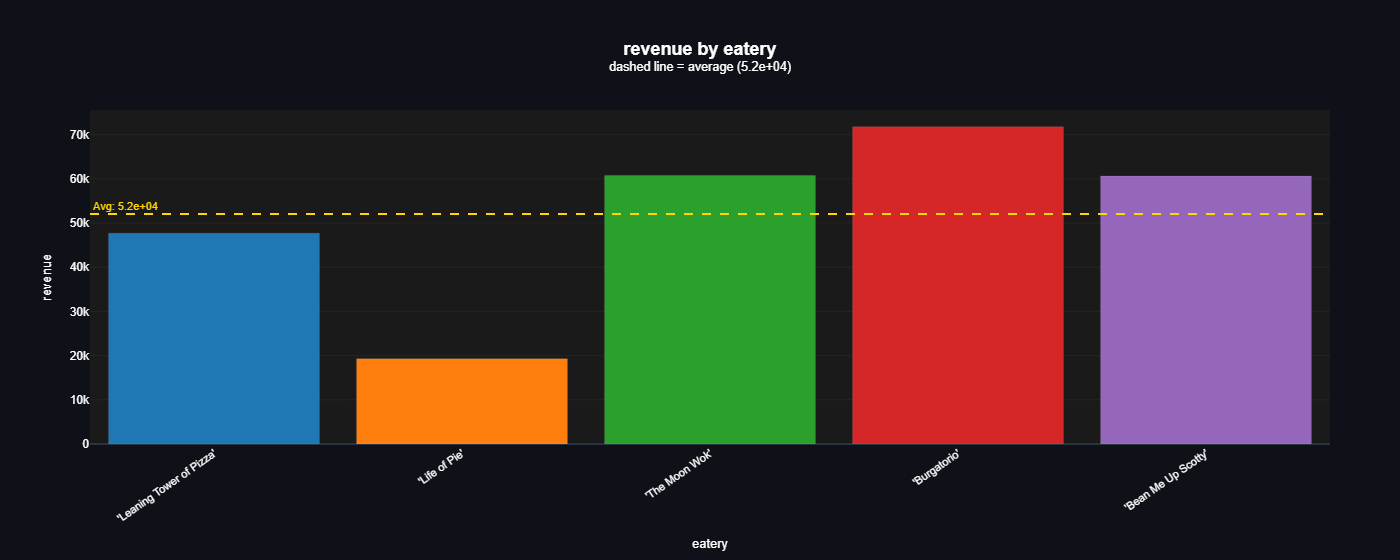

In [3]:
# revenue per eatery 

df_revenue_eatery = run_query('''
select meals.eatery,
       sum(meal_price * order_quantity) as revenue 
from meals
inner join orders using(meal_id)
group by eatery 
''')

per_eatery_barplot = bar_plot(df=df_revenue_eatery,
                              x='eatery', 
                              y='revenue', 
                              show_values=False, 
                              avg_line=True)
per_eatery_barplot

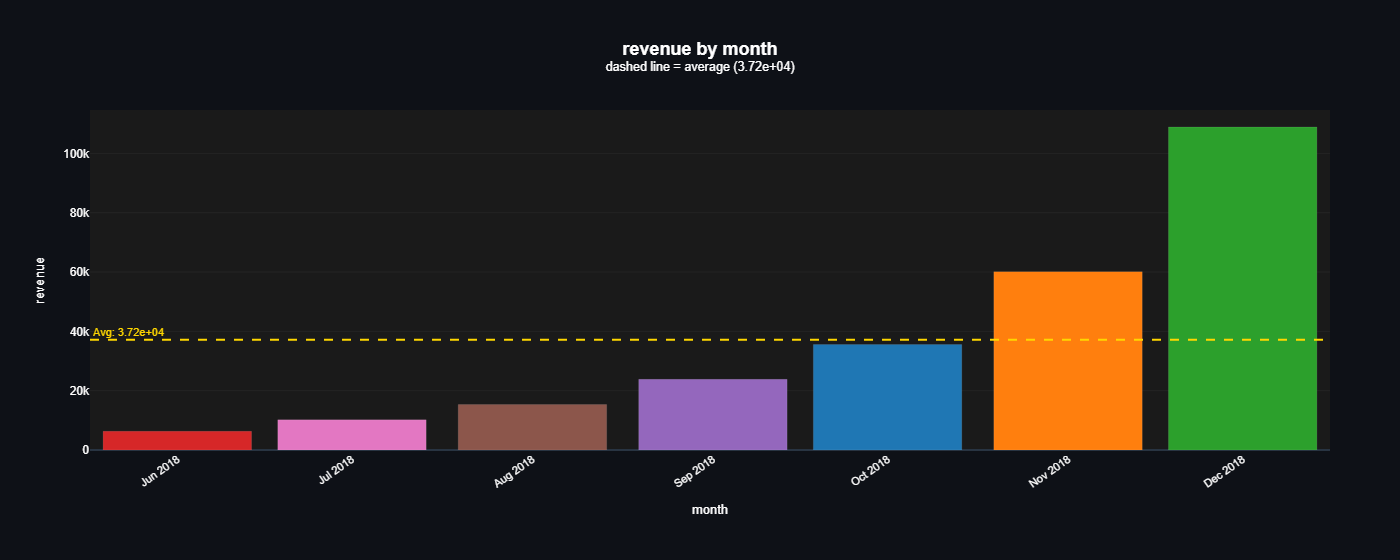

In [4]:
# revenue per month 

df_revenue_month = run_query('''
select date_trunc('month', orders.order_date)::date as month,
       sum(meal_price * order_quantity) as revenue     
from meals 
inner join orders using(meal_id)
group by month;
''')

revenue_mounth_barplot = bar_plot(df=df_revenue_month,
                                   x='month',
                                   y='revenue',
                                   avg_line=True,
                                   show_values=False)
revenue_mounth_barplot

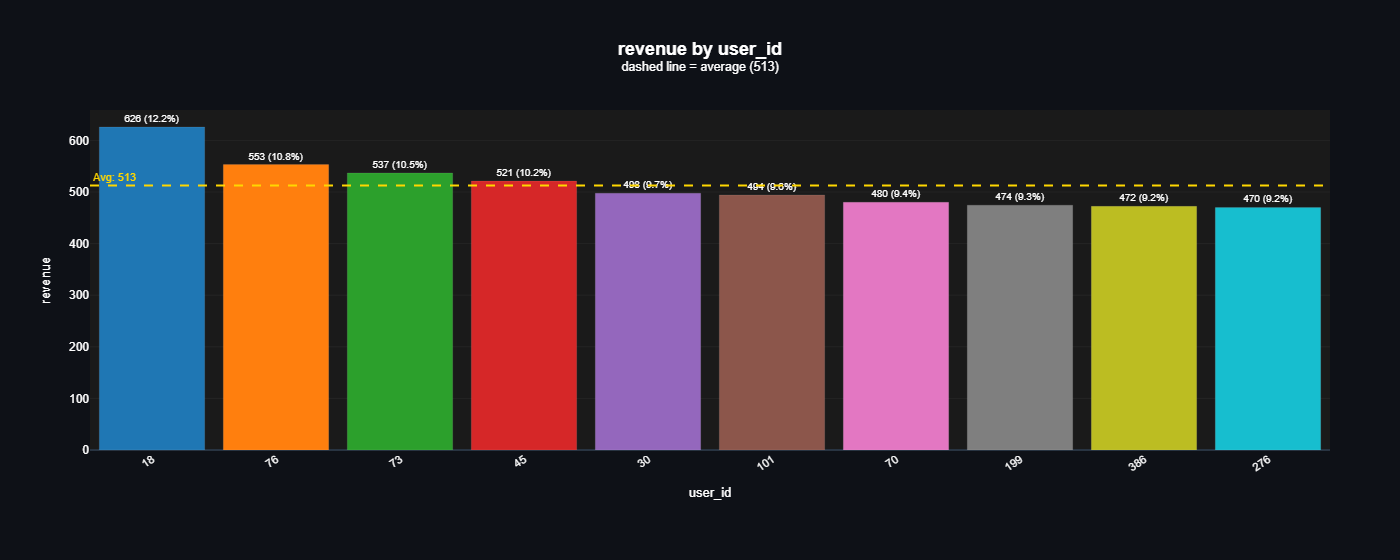

In [5]:
# revenue per customer 

df_revenue_customer = run_query('''
select user_id,
       sum(order_quantity * meal_price) as revenue
from orders 
inner join meals using(meal_id)
group by user_id
order by revenue desc
limit 10
''')

revenue_customer_barplot = bar_plot(df=df_revenue_customer,
                                    x='user_id',
                                    y='revenue',
                                    show_pct_of_total=True,
                                    avg_line=True)
revenue_customer_barplot

<div class="alert alert-block alert-success">


## calculating **profit** in different forms (profit = revenue - cost)
- profit per month 
- profit per customer 

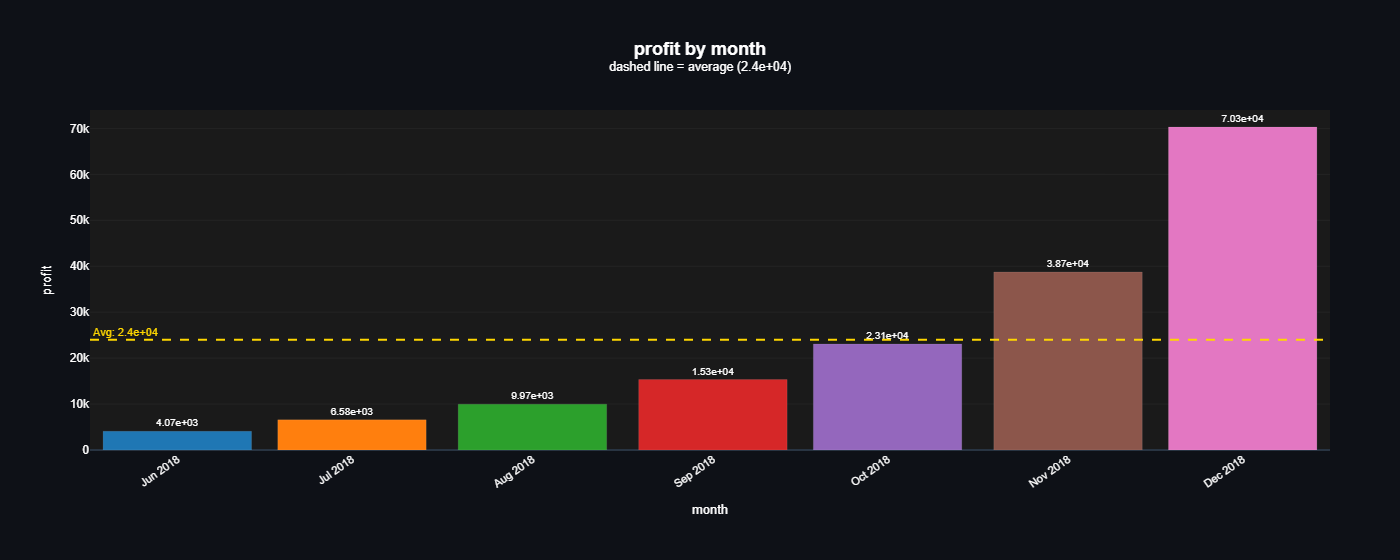

In [6]:
# profit per month

df_profit_month = run_query('''
select date_trunc('month', orders.order_date)::date as month,
       sum(order_quantity * (meal_price - meal_cost)) as profit 
from orders 
inner join meals using(meal_id)
group by month
order by month;
''')

profit_month_barplot = bar_plot(df=df_profit_month, x='month', y='profit', avg_line=True)
profit_month_barplot


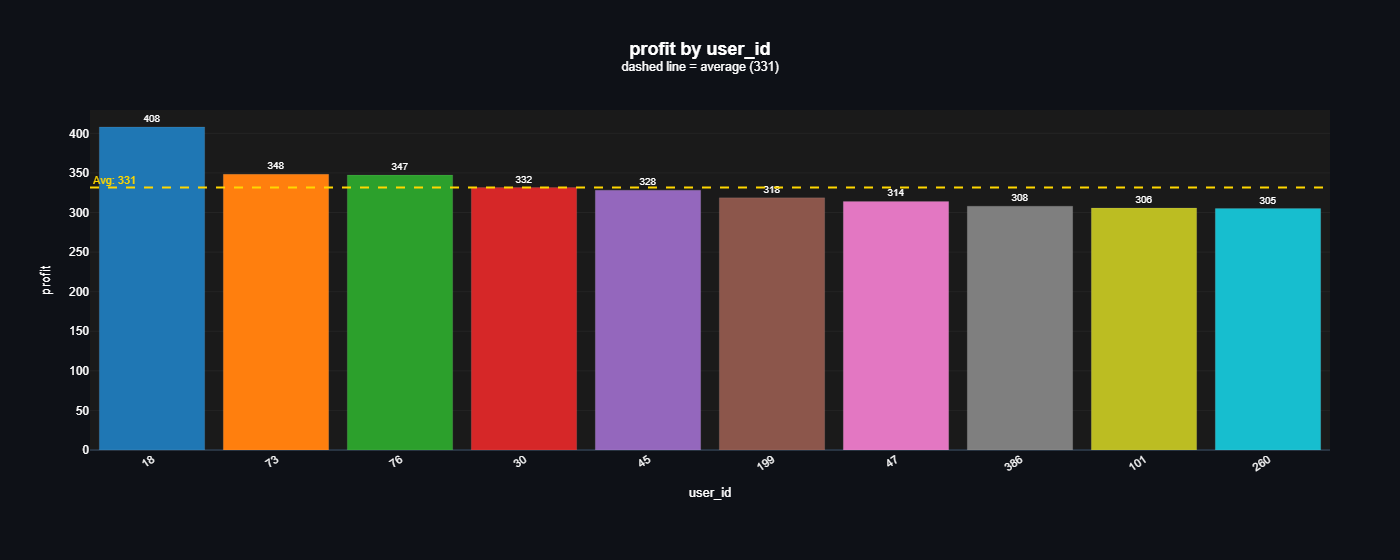

In [8]:
# profit per user

df_profit_customer = run_query('''
select user_id,
       sum(order_quantity * (meal_price - meal_cost)) as profit 
from orders 
inner join meals using(meal_id)
group by user_id
order by profit desc
limit 10;
''')

profit_customer_barplot = bar_plot(df=df_profit_customer,
                                   x='user_id',
                                   y='profit',
                                   avg_line=True)

profit_customer_barplot

<div class="alert alert-block alert-success">

### do customer that spend more also generate more profit?

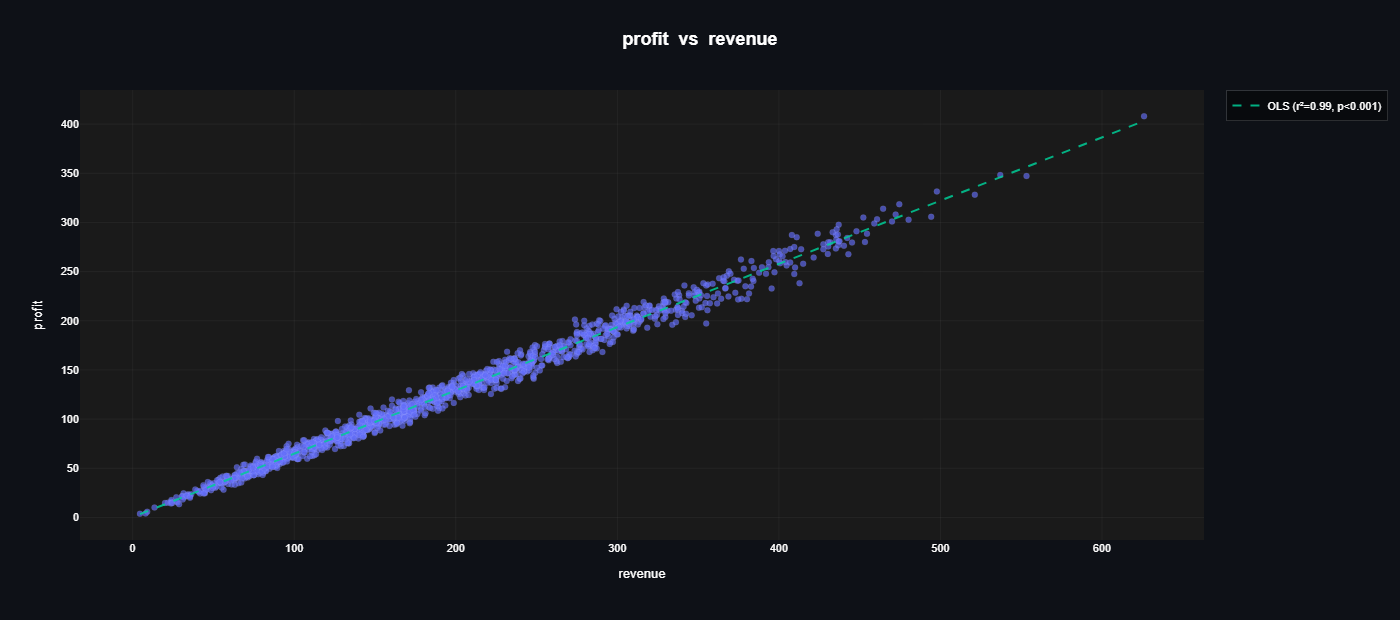

In [14]:
df_revenue_profit_scatter = run_query('''
select distinct user_id,
	   sum(order_quantity * meal_price) over(partition by user_id) as revenue,
	   sum(order_quantity * (meal_price - meal_cost)) over(partition by user_id) as profit
from orders
inner join meals using(meal_id);
''')

revenue_profit_scatter_plot = scatter_plot(df=df_revenue_profit_scatter,
                                           x='revenue',
                                           y='profit')
                                           
revenue_profit_scatter_plot

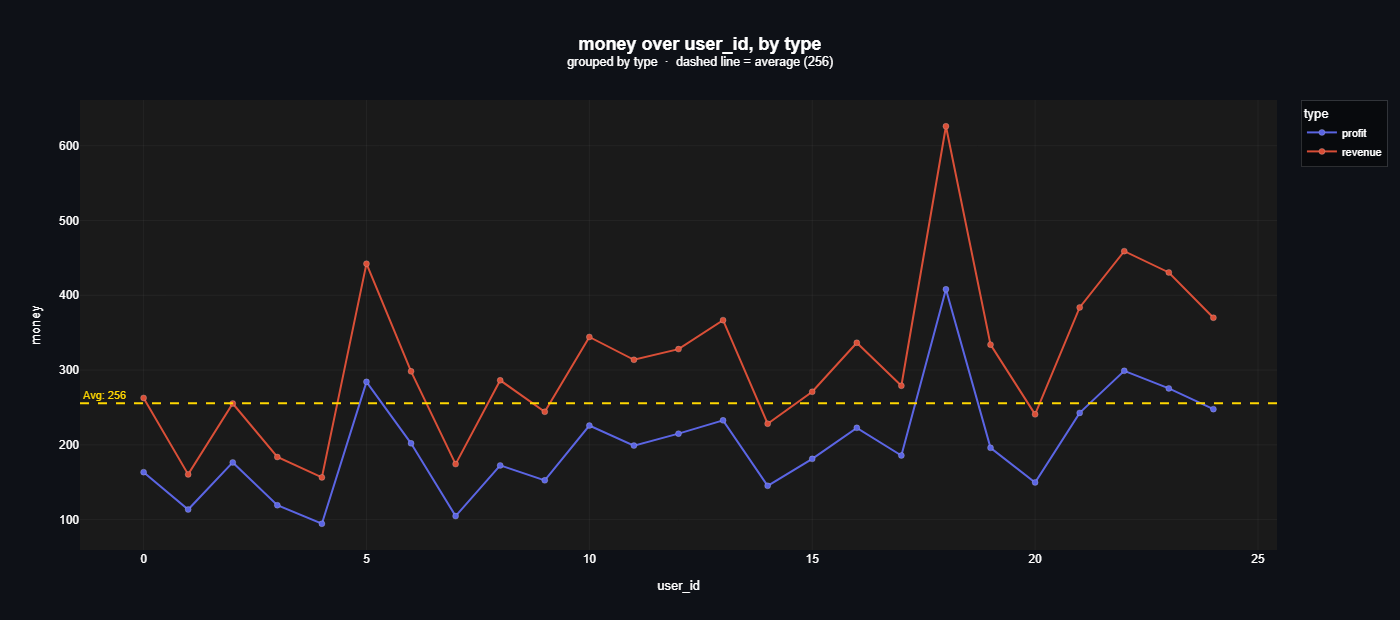

In [16]:
df_revenue_profit_group = run_query('''
select user_id,
	   sum(order_quantity * meal_price) as money,
	   'revenue' as type
from orders inner join meals using(meal_id)
group by user_id 
union all
select user_id,
	   sum(order_quantity * (meal_price - meal_cost)) as money,
	   'profit' as type
from orders inner join meals using(meal_id)
group by user_id
order by user_id
limit 50;
''')

revenue_profit_lineplot = line_plot(df=df_revenue_profit_group,
                                    x='user_id',
                                    y='money',
                                    group_col='type',
                                    avg_line=True,
                                    )
revenue_profit_lineplot

<div class="alert alert-block alert-success">

### does the same pattern appears when we aggrete by time?

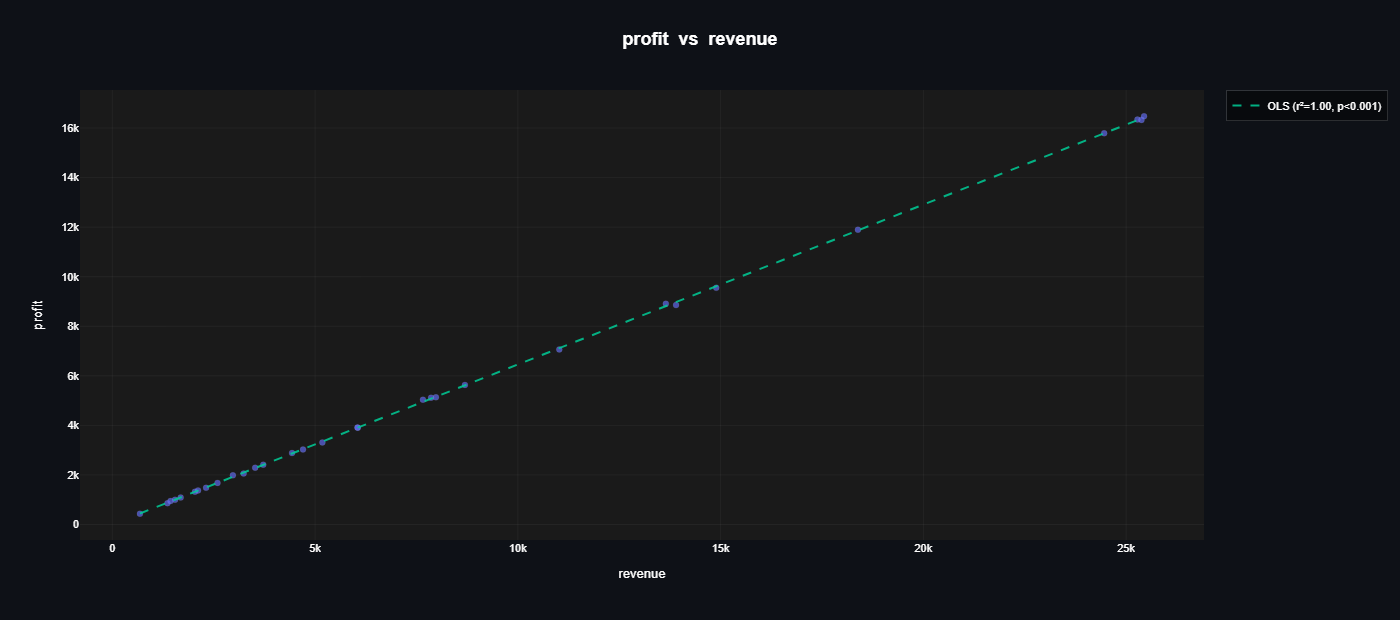

In [25]:
df_revenue_profit_scatter_timeagg = run_query('''
select distinct date_trunc('week', order_date)::date as week,
	   sum(order_quantity * meal_price) over(partition by date_trunc('week', order_date)::date) as revenue,
	   sum(order_quantity * (meal_price - meal_cost)) over(partition by date_trunc('week', order_date)::date) as profit
from orders
inner join meals using(meal_id);
''')

revenue_profit_timeagg_scatter_plot = scatter_plot(df=df_revenue_profit_scatter_timeagg,
                                           x='revenue',
                                           y='profit')
                                           
revenue_profit_timeagg_scatter_plot